# FCN3 vs GraphCast Operational: 10 m Wind Speed Comparison

Compares **FCN3** (station-extracted, 6 h lead) and **GraphCast Operational** (nearest grid-point extracted, ≤ 24 h lead) against hourly station observations at three northern Norwegian weather stations.

| Station ID | Name | Lat | Lon |
|---|---|---|---|
| SN88690 | Hekkingen Fyr | 69.60 N | 17.83 E |
| SN90490 | Tromsø-Langnes | 69.68 N | 18.91 E |
| SN90760 | Fakken | 70.10 N | 20.11 E |

**Metrics**: MSE and RMSE (m/s).

In [61]:
import warnings
warnings.filterwarnings('ignore')

import zarr
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.dates as mdates
from pathlib import Path

print('zarr   :', zarr.__version__)
print('numpy  :', np.__version__)
print('pandas :', pd.__version__)

zarr   : 3.1.6
numpy  : 2.4.4
pandas : 3.0.3


In [62]:
# ── Paths ──────────────────────────────────────────────────────────────────
FCN3_DIR = Path('/cluster/work/projects/nn8106k/siyan/WF-experiments/outputs/fcn3_station_weekly_tmp')
GC_DIR   = Path('/cluster/work/projects/nn8106k/siyan/WF-experiments/outputs/graphcast_operational_cds_weekly_tmp')
OBS_DIR  = Path('/cluster/home/siyan/github/WF-experiments/experiments/outputs/wind_obs')

# ── Figure output directory ─────────────────────────────────────────────────
FIG_DIR  = Path('/cluster/home/siyan/github/WF-experiments/experiments/notebooks/figures')
FIG_DIR.mkdir(parents=True, exist_ok=True)
print(f'Figures → {FIG_DIR}')

# ── Station metadata ────────────────────────────────────────────────────────
STATIONS = {
    'SN88690': {'name': 'Hekkingen Fyr',  'lat': 69.6005,  'lon': 17.8317},
    'SN90490': {'name': 'Tromsø-Langnes', 'lat': 69.6767,  'lon': 18.9133},
    'SN90760': {'name': 'Fakken',          'lat': 70.10426, 'lon': 20.11451},
}

OBS_FILES = {
    'SN88690': 'SN88690_Hekkingen_Fyr.csv',
    'SN90490': 'SN90490_Tromsoe_Langnes.csv',
    'SN90760': 'SN90760_Fakken.csv',
}

# ── Plot colours ────────────────────────────────────────────────────────────
CLR = {
    'FCN3':       '#E74C3C',
    'GraphCast':  '#2980B9',
    'Obs':        '#27AE60',
    'ERA5':       '#8E44AD',   # ERA5 analysis baseline (lead = 0 h)
}

Figures → /cluster/home/siyan/github/WF-experiments/experiments/notebooks/figures


## 1  Load Observations

In [63]:
def load_observations(obs_dir: Path) -> pd.DataFrame:
    dfs = []
    for sid, fname in OBS_FILES.items():
        df = pd.read_csv(obs_dir / fname)
        df['valid_time'] = pd.to_datetime(df['time'], utc=True).dt.tz_localize(None)
        df['station']    = sid
        df = df.rename(columns={'wind_speed': 'obs_wind'})
        dfs.append(df[['station', 'valid_time', 'obs_wind']].dropna(subset=['obs_wind']))
    obs = pd.concat(dfs, ignore_index=True)
    return obs

obs_df = load_observations(OBS_DIR)
print(f'Observations: {len(obs_df):,} rows across {obs_df["station"].nunique()} stations')
print(f'  Time range : {obs_df["valid_time"].min()}  →  {obs_df["valid_time"].max()}')
obs_df.head(3)

Observations: 202,235 rows across 3 stations
  Time range : 2009-01-01 00:00:00  →  2025-12-31 23:00:00


,station,valid_time,obs_wind
0,SN88690,2009-01-01 00:00:00,15.1
1,SN88690,2009-01-01 01:00:00,12.9
2,SN88690,2009-01-01 02:00:00,11.2


## 2  Load FCN3 Station Wind Data

In [64]:
def _to_str(val):
    if isinstance(val, (bytes, bytearray)):
        return val.decode('utf-8')
    return str(val)


def load_fcn3_weekly(zarr_path: Path, lead_h: float = 6.0) -> pd.DataFrame:
    """Return FCN3 predictions at the requested lead time from one weekly zarr."""
    g = zarr.open_group(str(zarr_path), mode='r')

    # Station IDs
    stations = [_to_str(s) for s in g['station'][:]]

    # Decode init times  (int64 hours since epoch)
    time_raw  = g['time'][:]
    time_attrs = dict(g['time'].attrs)
    units      = time_attrs.get('units', 'hours since 2009-01-01 00:00:00')
    epoch      = pd.Timestamp(units.replace('hours since ', '').strip())
    init_times = pd.DatetimeIndex(
        [epoch + pd.Timedelta(hours=int(h)) for h in time_raw]
    )

    # Lead-time vector (int64 hours)
    lt_raw   = g['lead_time'][:]
    lt_hours = lt_raw.astype(float)
    lt_idx   = int(np.argmin(np.abs(lt_hours - lead_h)))
    lt_used  = float(lt_hours[lt_idx])

    # Wind speed: shape [station, time, lead_time]
    ws = g['wind_speed_10m'][:]

    records = []
    for s_i, sid in enumerate(stations):
        for t_i, init_t in enumerate(init_times):
            wind = float(ws[s_i, t_i, lt_idx])
            if np.isnan(wind):
                continue
            records.append({
                'station':     sid,
                'init_time':   init_t,
                'lead_time_h': lt_used,
                'valid_time':  init_t + pd.Timedelta(hours=lt_used),
                'fcn3_wind':   wind,
            })
    return pd.DataFrame(records)


# ── Load all FCN3 weekly files ──────────────────────────────────────────────
fcn3_files = sorted(FCN3_DIR.glob('fcn3_station_wind_*.zarr'))
print(f'FCN3 weekly files: {len(fcn3_files)}')

if not fcn3_files:
    raise FileNotFoundError(f'No FCN3 zarr files found in {FCN3_DIR}')

fcn3_parts = []
for f in fcn3_files:
    print(f'  {f.name} ...', end=' ', flush=True)
    df = load_fcn3_weekly(f, lead_h=6.0)
    fcn3_parts.append(df)
    print(f'{len(df)} records')

fcn3_df = (
    pd.concat(fcn3_parts, ignore_index=True)
    .drop_duplicates(subset=['station', 'valid_time'])
    .sort_values(['station', 'valid_time'])
    .reset_index(drop=True)
)
print(f'\nFCN3 total : {len(fcn3_df):,} records')
print(f'Valid range: {fcn3_df["valid_time"].min()}  →  {fcn3_df["valid_time"].max()}')
fcn3_df.head(3)

FCN3 weekly files: 6
  fcn3_station_wind_20090101_20090107.zarr ... 84 records
  fcn3_station_wind_20090108_20090114.zarr ... 84 records
  fcn3_station_wind_20090115_20090121.zarr ... 84 records
  fcn3_station_wind_20090122_20090128.zarr ... 84 records
  fcn3_station_wind_20090129_20090204.zarr ... 84 records
  fcn3_station_wind_20090205_20090211.zarr ... 84 records

FCN3 total : 504 records
Valid range: 2009-01-01 06:00:00  →  2009-02-12 00:00:00


,station,init_time,lead_time_h,valid_time,fcn3_wind
0,SN88690,2009-01-01 00:00:00,6.0,2009-01-01 06:00:00,7.454719
1,SN88690,2009-01-01 06:00:00,6.0,2009-01-01 12:00:00,5.750121
2,SN88690,2009-01-01 12:00:00,6.0,2009-01-01 18:00:00,6.747942


In [65]:
# ── Load ERA5 analysis values (FCN3 zarr lead_time = 0 h) ──────────────────
# lead_time=0 stores the ERA5 input used to initialise FCN3.
# valid_time = init_time + 0 h = the ERA5 analysis time itself.
# This serves as a "no-forecast" baseline: how good is ERA5 alone?
era5_parts = []
for f in fcn3_files:
    df = load_fcn3_weekly(f, lead_h=0.0)
    era5_parts.append(
        df[['station', 'valid_time', 'fcn3_wind']].rename(
            columns={'fcn3_wind': 'era5_wind'}
        )
    )

era5_df = (
    pd.concat(era5_parts, ignore_index=True)
    .drop_duplicates(subset=['station', 'valid_time'])
    .sort_values(['station', 'valid_time'])
    .reset_index(drop=True)
)
print(f'ERA5 analysis : {len(era5_df):,} records')
print(f'Valid range   : {era5_df["valid_time"].min()}  →  {era5_df["valid_time"].max()}')
era5_df.head(3)

ERA5 analysis : 504 records
Valid range   : 2009-01-01 00:00:00  →  2009-02-11 18:00:00


,station,valid_time,era5_wind
0,SN88690,2009-01-01 00:00:00,7.632271
1,SN88690,2009-01-01 06:00:00,5.994576
2,SN88690,2009-01-01 12:00:00,5.671018


## 3  Load GraphCast Data and Extract Station Grid Points

In [66]:
def _nearest_idx(lats, lons, target_lat, target_lon):
    lat_i = int(np.argmin(np.abs(lats - target_lat)))
    lon_i = int(np.argmin(np.abs(lons - (target_lon % 360))))
    return lat_i, lon_i


def load_gc_daily(zarr_path: Path, stn_idx: dict) -> pd.DataFrame:
    """
    Extract station wind speed from one GraphCast daily zarr.
    stn_idx : {station_id: (lat_i, lon_i)}
    Returns DataFrame: station, init_time, lead_time_h, valid_time, gc_wind.
    """
    g = zarr.open_group(str(zarr_path), mode='r')

    # Decode init time (numpy.datetime64 in nanoseconds)
    time_raw = g['time'][:]
    if np.issubdtype(time_raw.dtype, np.datetime64):
        init_time = pd.Timestamp(time_raw[0])
    else:
        init_time = pd.Timestamp(int(time_raw[0]), unit='ns')

    # Decode lead times (timedelta64[h] or int hours)
    lt_raw = g['lead_time'][:]
    if np.issubdtype(lt_raw.dtype, np.timedelta64):
        lead_hours = (lt_raw / np.timedelta64(1, 'h')).astype(float)
    else:
        lead_hours = lt_raw.astype(float)

    # Load u10m, v10m – shape [time=1, lead_time, lat, lon]
    u10m = g['u10m'][:]
    v10m = g['v10m'][:]
    ws   = np.sqrt(u10m ** 2 + v10m ** 2)

    records = []
    for sid, (lat_i, lon_i) in stn_idx.items():
        for lt_i, lt_h in enumerate(lead_hours):
            records.append({
                'station':     sid,
                'init_time':   init_time,
                'lead_time_h': float(lt_h),
                'valid_time':  init_time + pd.Timedelta(hours=float(lt_h)),
                'gc_wind':     float(ws[0, lt_i, lat_i, lon_i]),
            })
    return pd.DataFrame(records)


# ── Build station→grid-index map ────────────────────────────────────────────
gc_files_all = sorted(GC_DIR.glob('graphcast_operational_cds_daily_*.zarr'))
print(f'GraphCast daily files found: {len(gc_files_all)}')

_g0     = zarr.open_group(str(gc_files_all[0]), mode='r')
gc_lats = _g0['lat'][:]
gc_lons = _g0['lon'][:]
print(f'GC grid: lat {gc_lats.min():.2f}→{gc_lats.max():.2f}  lon {gc_lons.min():.2f}→{gc_lons.max():.2f}')

stn_idx = {}
for sid, info in STATIONS.items():
    lat_i, lon_i = _nearest_idx(gc_lats, gc_lons, info['lat'], info['lon'])
    stn_idx[sid] = (lat_i, lon_i)
    print(f'  {sid}  target=({info["lat"]:.4f}N, {info["lon"]:.4f}E)  '
          f'→ grid=({gc_lats[lat_i]:.2f}N, {gc_lons[lon_i]:.2f}E)  '
          f'[lat_i={lat_i}, lon_i={lon_i}]')

GraphCast daily files found: 229
GC grid: lat -90.00→90.00  lon 0.00→359.75
  SN88690  target=(69.6005N, 17.8317E)  → grid=(69.50N, 17.75E)  [lat_i=82, lon_i=71]
  SN90490  target=(69.6767N, 18.9133E)  → grid=(69.75N, 19.00E)  [lat_i=81, lon_i=76]
  SN90760  target=(70.1043N, 20.1145E)  → grid=(70.00N, 20.00E)  [lat_i=80, lon_i=80]


In [67]:
# ── Load all GC daily files (may take a few minutes) ───────────────────────
gc_parts = []
failed   = []
for i, f in enumerate(gc_files_all):
    if i % 20 == 0:
        print(f'  [{i+1}/{len(gc_files_all)}] {f.name}')
    try:
        gc_parts.append(load_gc_daily(f, stn_idx))
    except Exception as e:
        failed.append((f.name, str(e)))

if failed:
    print(f'\n{len(failed)} file(s) failed:')
    for name, err in failed:
        print(f'  {name}: {err}')

gc_df = pd.concat(gc_parts, ignore_index=True)

# For duplicate valid_times keep shortest lead_time (most recent init = more accurate)
gc_df = (
    gc_df
    .sort_values('lead_time_h')
    .drop_duplicates(subset=['station', 'valid_time'], keep='first')
    .sort_values(['station', 'valid_time'])
    .reset_index(drop=True)
)

print(f'GraphCast records (after dedup): {len(gc_df):,}')
print(f'Valid range: {gc_df["valid_time"].min()}  →  {gc_df["valid_time"].max()}')
print(f'Lead-time distribution:\n{gc_df["lead_time_h"].value_counts().sort_index()}')
gc_df.head(3)

  [1/229] graphcast_operational_cds_daily_20090101.zarr
  [21/229] graphcast_operational_cds_daily_20090121.zarr
  [41/229] graphcast_operational_cds_daily_20090521.zarr
  [61/229] graphcast_operational_cds_daily_20091008.zarr
  [81/229] graphcast_operational_cds_daily_20100225.zarr
  [101/229] graphcast_operational_cds_daily_20100715.zarr
  [121/229] graphcast_operational_cds_daily_20101202.zarr
  [141/229] graphcast_operational_cds_daily_20110421.zarr
  [161/229] graphcast_operational_cds_daily_20110908.zarr
  [181/229] graphcast_operational_cds_daily_20120126.zarr
  [201/229] graphcast_operational_cds_daily_20120614.zarr
  [221/229] graphcast_operational_cds_daily_20121101.zarr

205 file(s) failed:
  graphcast_operational_cds_daily_20090129.zarr: 'time'
  graphcast_operational_cds_daily_20090205.zarr: No group found in store '/cluster/work/projects/nn8106k/siyan/WF-experiments/outputs/graphcast_operational_cds_weekly_tmp/graphcast_operational_cds_daily_20090205.zarr' at path ''
  gr

,station,init_time,lead_time_h,valid_time,gc_wind
0,SN88690,2009-01-01,0.0,2009-01-01 00:00:00,7.632271
1,SN88690,2009-01-01,6.0,2009-01-01 06:00:00,6.827168
2,SN88690,2009-01-01,12.0,2009-01-01 12:00:00,6.296206


## 4  Align Datasets – Fair Comparison (06:00 UTC, 6 h Lead)

Filter all three sources to **valid_time = 06:00 UTC** only:
- FCN3: initialized 00:00 UTC + 6 h lead → valid 06:00 ✓
- GraphCast: initialized 00:00 UTC + 6 h lead → valid 06:00 ✓
- ERA5: analysis at 06:00 UTC (lead = 0 h) ✓

All three share the **same initialization time and valid time** — a strict apples-to-apples comparison.

In [68]:
# Normalize valid_time resolution to avoid pandas 3.0 dtype mismatches.
for _df in [fcn3_df, gc_df, obs_df, era5_df]:
    _df['valid_time'] = _df['valid_time'].astype('datetime64[us]')

# FCN3 ∩ GraphCast
merged = pd.merge(
    fcn3_df[['station', 'valid_time', 'fcn3_wind']],
    gc_df[['station',   'valid_time', 'gc_wind', 'lead_time_h']],
    on=['station', 'valid_time'], how='inner',
)
print(f'FCN3 ∩ GC          : {len(merged):,} records')

# ∩ Observations
merged = pd.merge(
    merged,
    obs_df[['station', 'valid_time', 'obs_wind']],
    on=['station', 'valid_time'], how='inner',
).dropna(subset=['fcn3_wind', 'gc_wind', 'obs_wind'])
print(f'FCN3 ∩ GC ∩ Obs    : {len(merged):,} records')

if len(merged) == 0:
    raise ValueError('No matching records after merge.')

# ∩ ERA5 analysis (left join)
merged = pd.merge(
    merged,
    era5_df[['station', 'valid_time', 'era5_wind']],
    on=['station', 'valid_time'], how='left',
)

# ── Fair comparison: keep only 06:00 UTC valid times ───────────────────────
# At 06:00, all three use the same 00:00 UTC init + 6 h lead → apples-to-apples.
merged = merged[merged['valid_time'].dt.hour == 6].copy()
print(f'Fair comparison (06:00 UTC, 6h lead): {len(merged):,} records')

if len(merged) == 0:
    raise ValueError('No records at 06:00 UTC after merge.')

print(f'\nPer station:')
print(merged.groupby('station').size().rename('N'))
print(f'\nValid-time range   : {merged["valid_time"].min()}  →  {merged["valid_time"].max()}')

# Remove stations with no matched data
_avail   = set(merged['station'].unique())
_missing = [s for s in list(STATIONS.keys()) if s not in _avail]
for s in _missing:
    print(f'\n  Note: {s} ({STATIONS[s]["name"]}) excluded — no obs overlap with forecast period.')
    del STATIONS[s]
if _missing:
    print(f'  Remaining: {list(STATIONS.keys())}')

merged.head(5)

FCN3 ∩ GC          : 288 records
FCN3 ∩ GC ∩ Obs    : 192 records
Fair comparison (06:00 UTC, 6h lead): 48 records

Per station:
station
SN88690    24
SN90490    24
Name: N, dtype: int64

Valid-time range   : 2009-01-01 06:00:00  →  2009-01-24 06:00:00

  Note: SN90760 (Fakken) excluded — no obs overlap with forecast period.
  Remaining: ['SN88690', 'SN90490']


,station,valid_time,fcn3_wind,gc_wind,lead_time_h,obs_wind,era5_wind
0,SN88690,2009-01-01 06:00:00,7.454719,6.827168,6.0,4.5,5.994576
4,SN88690,2009-01-02 06:00:00,4.498944,4.867903,6.0,9.4,4.634727
8,SN88690,2009-01-03 06:00:00,5.506467,3.606153,6.0,8.3,3.779517
12,SN88690,2009-01-04 06:00:00,6.157438,5.206478,6.0,8.8,4.537976
16,SN88690,2009-01-05 06:00:00,10.433131,9.804290,6.0,12.9,10.871882


## 5  Compute MSE and RMSE

In [69]:
def compute_metrics(df: pd.DataFrame) -> pd.DataFrame:
    rows = []
    groups = [*df.groupby('station'), ('All Stations', df)]
    for label, gdf in groups:
        if len(gdf) == 0:
            continue
        e_fcn3 = gdf['fcn3_wind'] - gdf['obs_wind']
        e_gc   = gdf['gc_wind']   - gdf['obs_wind']
        mse_f  = float((e_fcn3**2).mean())
        mse_g  = float((e_gc**2).mean())
        row = {
            'Station':   label,
            'N':         len(gdf),
            'FCN3 RMSE': float(np.sqrt(mse_f)),
            'GC RMSE':   float(np.sqrt(mse_g)),
            'FCN3 MSE':  mse_f,
            'GC MSE':    mse_g,
            'FCN3 Bias': float(e_fcn3.mean()),
            'GC Bias':   float(e_gc.mean()),
        }
        if 'era5_wind' in gdf.columns:
            sub_e = gdf.dropna(subset=['era5_wind'])
            if len(sub_e) > 0:
                e_era5 = sub_e['era5_wind'] - sub_e['obs_wind']
                mse_e  = float((e_era5**2).mean())
                row.update({
                    'ERA5 RMSE': float(np.sqrt(mse_e)),
                    'ERA5 MSE':  mse_e,
                    'ERA5 Bias': float(e_era5.mean()),
                })
        rows.append(row)
    return pd.DataFrame(rows).set_index('Station')


metrics = compute_metrics(merged)

print('=' * 90)
print('Fair Comparison: 00:00 UTC init + 6 h lead (valid 06:00 UTC)')
print('ERA5 Analysis (lead=0) | FCN3 (6h lead) | GraphCast (6h lead)')
print('=' * 90)
display_cols = ['N', 'ERA5 RMSE', 'FCN3 RMSE', 'GC RMSE',
                    'ERA5 MSE',  'FCN3 MSE',  'GC MSE',
                    'ERA5 Bias', 'FCN3 Bias', 'GC Bias']
print(metrics[display_cols].round(4).to_string())

Fair Comparison: 00:00 UTC init + 6 h lead (valid 06:00 UTC)
ERA5 Analysis (lead=0) | FCN3 (6h lead) | GraphCast (6h lead)
               N  ERA5 RMSE  FCN3 RMSE  GC RMSE  ERA5 MSE  FCN3 MSE   GC MSE  ERA5 Bias  FCN3 Bias  GC Bias
Station                                                                                                    
SN88690       24     4.6130     4.6803   4.9962   21.2801   21.9050  24.9616    -3.5157    -3.5025  -3.9190
SN90490       24     4.4667     4.2635   4.2420   19.9517   18.1774  17.9943    -3.5065    -3.1932  -3.3069
All Stations  48     4.5405     4.4767   4.6344   20.6159   20.0412  21.4779    -3.5111    -3.3479  -3.6130


## 6  Visualize: Time Series per Station

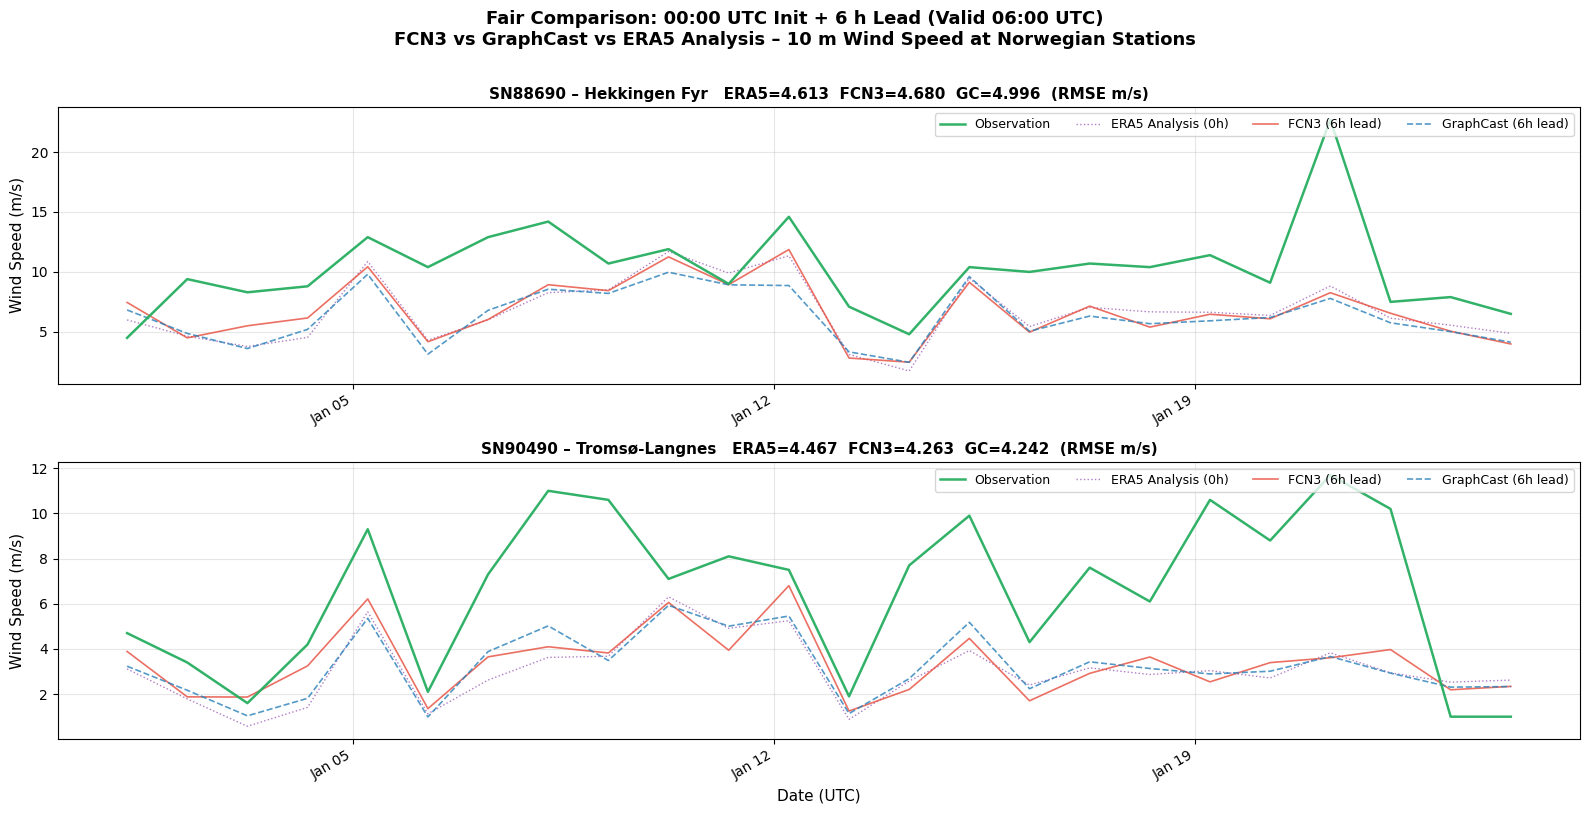

Saved: /cluster/home/siyan/github/WF-experiments/experiments/notebooks/figures/comparison_time_series.png


In [70]:
_n = len(STATIONS)
fig, axes = plt.subplots(_n, 1, figsize=(16, 4 * _n))
if _n == 1:
    axes = [axes]

for ax, (sid, info) in zip(axes, STATIONS.items()):
    sub = merged[merged['station'] == sid].sort_values('valid_time')

    ax.plot(sub['valid_time'], sub['obs_wind'],
            color=CLR['Obs'],       lw=1.8, label='Observation',        alpha=0.95, zorder=4)
    ax.plot(sub['valid_time'], sub['era5_wind'],
            color=CLR['ERA5'],      lw=1.0, label='ERA5 Analysis (0h)',
            alpha=0.70, zorder=1, linestyle=':')
    ax.plot(sub['valid_time'], sub['fcn3_wind'],
            color=CLR['FCN3'],      lw=1.2, label='FCN3 (6h lead)',      alpha=0.80, zorder=2)
    ax.plot(sub['valid_time'], sub['gc_wind'],
            color=CLR['GraphCast'], lw=1.2, label='GraphCast (6h lead)',
            alpha=0.80, zorder=2, linestyle='--')

    rmse_f = metrics.loc[sid, 'FCN3 RMSE']
    rmse_g = metrics.loc[sid, 'GC RMSE']
    rmse_e = metrics.loc[sid, 'ERA5 RMSE'] if 'ERA5 RMSE' in metrics.columns else float('nan')
    ax.set_title(
        f'{sid} – {info["name"]}   '
        f'ERA5={rmse_e:.3f}  FCN3={rmse_f:.3f}  GC={rmse_g:.3f}  (RMSE m/s)',
        fontsize=11, fontweight='bold'
    )
    ax.set_ylabel('Wind Speed (m/s)', fontsize=11)
    ax.legend(loc='upper right', fontsize=9, ncol=4)
    ax.grid(True, alpha=0.3)
    ax.xaxis.set_major_formatter(mdates.DateFormatter('%b %d'))
    ax.xaxis.set_major_locator(mdates.WeekdayLocator(byweekday=0))
    plt.setp(ax.xaxis.get_majorticklabels(), rotation=30, ha='right')

axes[-1].set_xlabel('Date (UTC)', fontsize=11)
fig.suptitle(
    'Fair Comparison: 00:00 UTC Init + 6 h Lead (Valid 06:00 UTC)\n'
    'FCN3 vs GraphCast vs ERA5 Analysis – 10 m Wind Speed at Norwegian Stations',
    fontsize=13, fontweight='bold', y=1.01
)
plt.tight_layout()
out = FIG_DIR / 'comparison_time_series.png'
plt.savefig(out, dpi=130, bbox_inches='tight')
plt.show()
print(f'Saved: {out}')

## 7  Visualize: MSE and RMSE Bar Charts

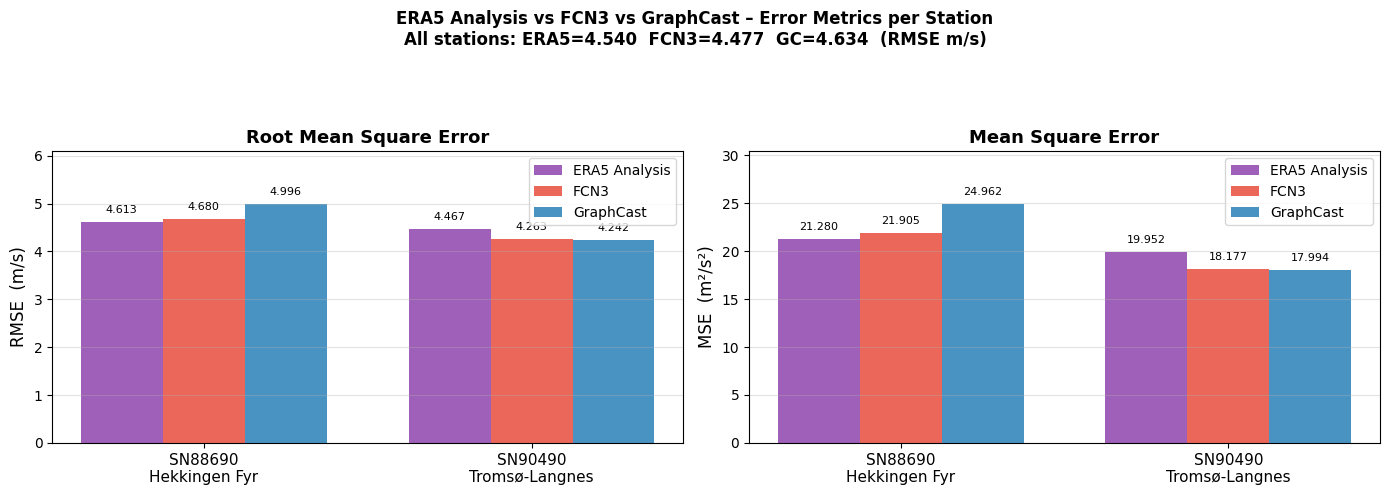

Saved: /cluster/home/siyan/github/WF-experiments/experiments/notebooks/figures/comparison_metrics_bar.png


In [71]:
sids   = list(STATIONS.keys())
labels = [f'{sid}\n{STATIONS[sid]["name"]}' for sid in sids]
mdf    = metrics.loc[sids]

x, w = np.arange(len(sids)), 0.25
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

for ax, (metric, ylabel, title) in zip(
    axes,
    [('RMSE', 'RMSE  (m/s)',  'Root Mean Square Error'),
     ('MSE',  'MSE  (m²/s²)', 'Mean Square Error')],
):
    b0 = ax.bar(x - w, mdf[f'ERA5 {metric}'], w,
                label='ERA5 Analysis', color=CLR['ERA5'],      alpha=0.85)
    b1 = ax.bar(x,     mdf[f'FCN3 {metric}'], w,
                label='FCN3',          color=CLR['FCN3'],      alpha=0.85)
    b2 = ax.bar(x + w, mdf[f'GC {metric}'],   w,
                label='GraphCast',     color=CLR['GraphCast'], alpha=0.85)
    ax.set_xticks(x);  ax.set_xticklabels(labels, fontsize=11)
    ax.set_ylabel(ylabel, fontsize=12)
    ax.set_title(title, fontsize=13, fontweight='bold')
    ax.legend(fontsize=10);  ax.grid(axis='y', alpha=0.35)

    all_bars   = [*b0, *b1, *b2]
    max_height = max(bar.get_height() for bar in all_bars)
    offset     = max_height * 0.03
    for bar in all_bars:
        ax.text(bar.get_x() + bar.get_width() / 2, bar.get_height() + offset,
                f'{bar.get_height():.3f}', ha='center', va='bottom', fontsize=8)
    ax.set_ylim(0, max_height * 1.22)

ov = metrics.loc['All Stations']
fig.suptitle(
    'ERA5 Analysis vs FCN3 vs GraphCast – Error Metrics per Station\n'
    f'All stations: ERA5={ov["ERA5 RMSE"]:.3f}  FCN3={ov["FCN3 RMSE"]:.3f}  '
    f'GC={ov["GC RMSE"]:.3f}  (RMSE m/s)',
    fontsize=12, fontweight='bold'
)
plt.tight_layout(rect=[0, 0, 1, 0.88])
out = FIG_DIR / 'comparison_metrics_bar.png'
plt.savefig(out, dpi=130, bbox_inches='tight')
plt.show()
print(f'Saved: {out}')

## 8  Visualize: RMSE and MSE Line Charts Over Time

Per-day RMSE and MSE for each model, shown per station and averaged across all stations.

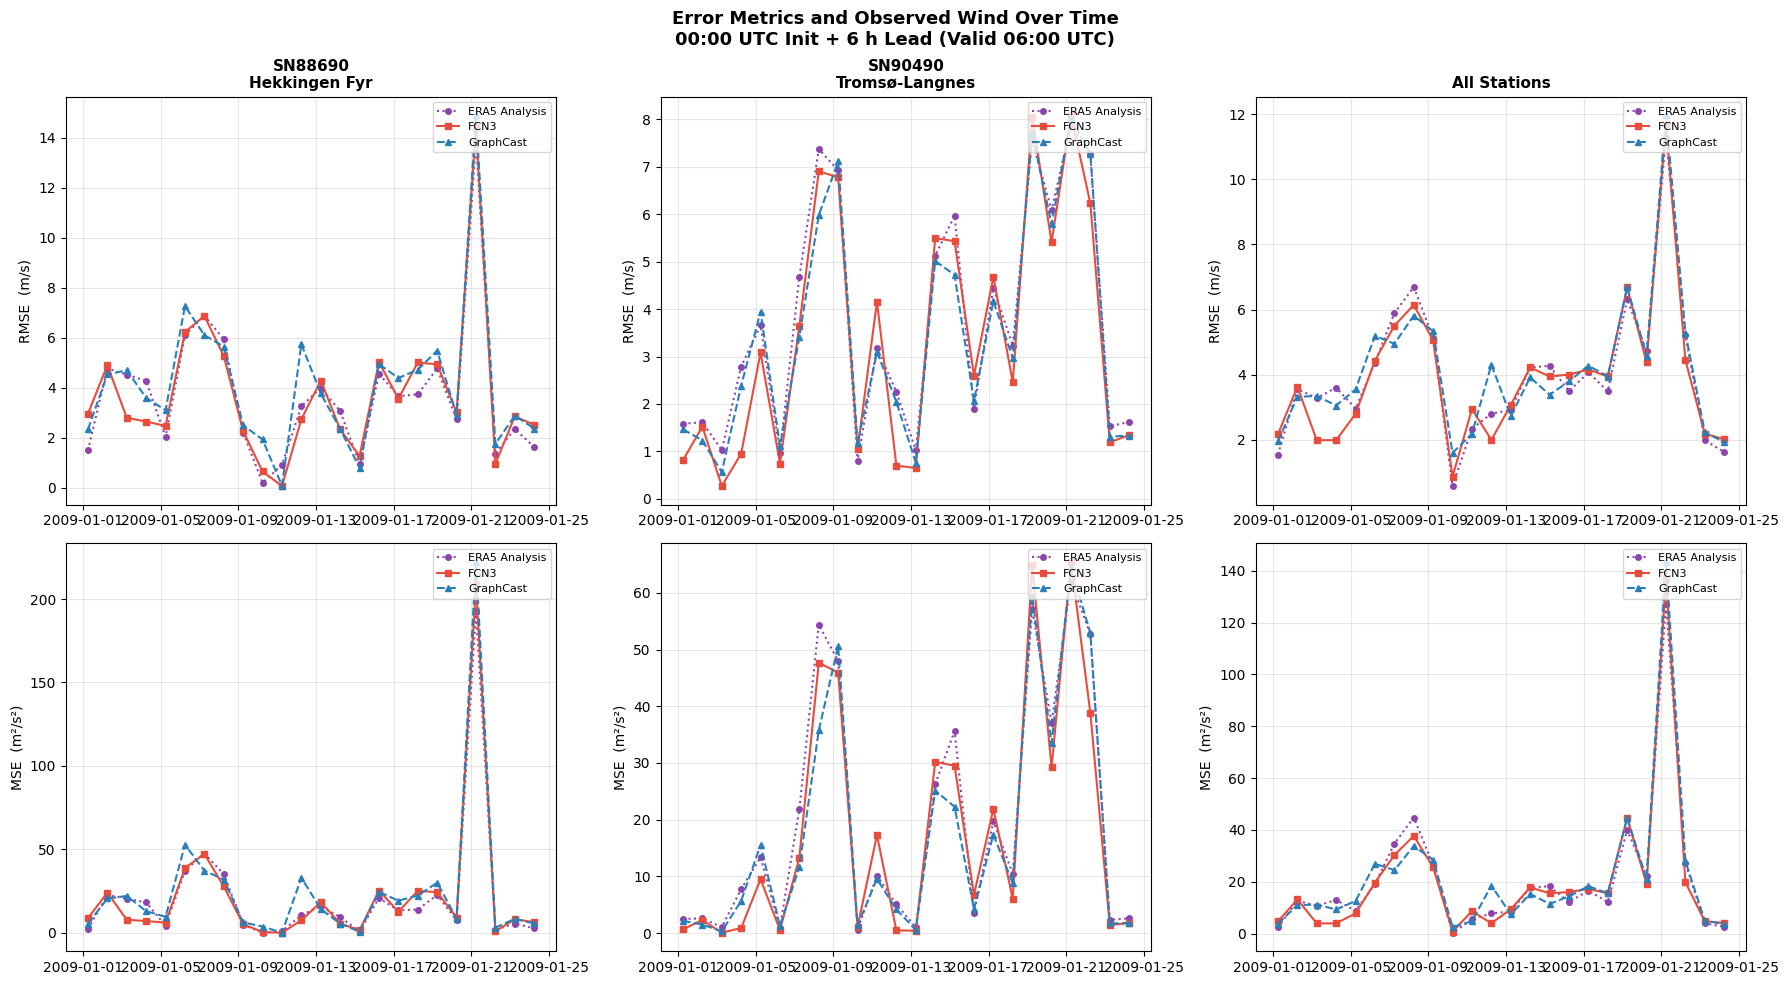

Saved: /cluster/home/siyan/github/WF-experiments/experiments/notebooks/figures/comparison_metrics_line.png


In [72]:
err = merged.copy()
err['se_fcn3'] = (err['fcn3_wind'] - err['obs_wind']) ** 2
err['se_gc']   = (err['gc_wind']   - err['obs_wind']) ** 2
err['se_era5'] = (err['era5_wind'] - err['obs_wind']) ** 2

# Per-station groups: (time, SE array, obs_wind)
plot_groups = {}
for sid in STATIONS:
    sub = err[err['station'] == sid].sort_values('valid_time')
    plot_groups[f'{sid}\n{STATIONS[sid]["name"]}'] = (
        sub['valid_time'].values,
        sub[['se_era5', 'se_fcn3', 'se_gc']].values.T,
        sub['obs_wind'].values,
    )

# All-stations group (mean SE and mean obs across stations per valid_time)
all_sub = err.groupby('valid_time')[['se_era5', 'se_fcn3', 'se_gc', 'obs_wind']].mean().sort_index()
plot_groups['All Stations'] = (
    all_sub.index.values,
    all_sub[['se_era5', 'se_fcn3', 'se_gc']].values.T,
    all_sub['obs_wind'].values,
)

n_cols = len(plot_groups)
fig, axes = plt.subplots(2, n_cols, figsize=(6 * n_cols, 10), squeeze=False)
fig.suptitle(
    'Error Metrics and Observed Wind Over Time\n'
    '00:00 UTC Init + 6 h Lead (Valid 06:00 UTC)',
    fontsize=13, fontweight='bold'
)

for col, (label, (t, (se_era5, se_fcn3, se_gc), obs_wind)) in enumerate(plot_groups.items()):
    # Row 0: RMSE
    ax = axes[0, col]
    ax.plot(t, np.sqrt(se_era5), color=CLR['ERA5'],      lw=1.5, linestyle=':',  marker='o', ms=4, label='ERA5 Analysis')
    ax.plot(t, np.sqrt(se_fcn3), color=CLR['FCN3'],      lw=1.5, linestyle='-',  marker='s', ms=4, label='FCN3')
    ax.plot(t, np.sqrt(se_gc),   color=CLR['GraphCast'], lw=1.5, linestyle='--', marker='^', ms=4, label='GraphCast')
    ax.set_title(label, fontsize=11, fontweight='bold')
    ax.set_ylabel('RMSE  (m/s)', fontsize=10)
    ax.grid(True, alpha=0.3)
    ax.legend(fontsize=8, loc='upper right')

    # Row 1: MSE
    ax = axes[1, col]
    ax.plot(t, se_era5, color=CLR['ERA5'],      lw=1.5, linestyle=':',  marker='o', ms=4, label='ERA5 Analysis')
    ax.plot(t, se_fcn3, color=CLR['FCN3'],      lw=1.5, linestyle='-',  marker='s', ms=4, label='FCN3')
    ax.plot(t, se_gc,   color=CLR['GraphCast'], lw=1.5, linestyle='--', marker='^', ms=4, label='GraphCast')
    ax.set_ylabel('MSE  (m²/s²)', fontsize=10)
    ax.grid(True, alpha=0.3)
    ax.legend(fontsize=8, loc='upper right')

    # # Row 2: Observed wind speed (reference)
    # ax = axes[2, col]
    # ax.plot(t, obs_wind, color=CLR['Obs'], lw=1.8, marker='o', ms=4, label='Observation')
    # ax.set_ylabel('Obs Wind  (m/s)', fontsize=10)
    # ax.set_xlabel('Date (UTC)', fontsize=10)
    # ax.grid(True, alpha=0.3)
    # ax.legend(fontsize=8, loc='upper right')

    # for row in range(3):
    #     ax = axes[row, col]
    #     ax.xaxis.set_major_formatter(mdates.DateFormatter('%b %d'))
    #     ax.xaxis.set_major_locator(mdates.WeekdayLocator(byweekday=0))
    #     plt.setp(ax.xaxis.get_majorticklabels(), rotation=30, ha='right')

plt.tight_layout()
out = FIG_DIR / 'comparison_metrics_line.png'
plt.savefig(out, dpi=130, bbox_inches='tight')
plt.show()
print(f'Saved: {out}')

## 8  Visualize: Observed vs Predicted Scatter Plots

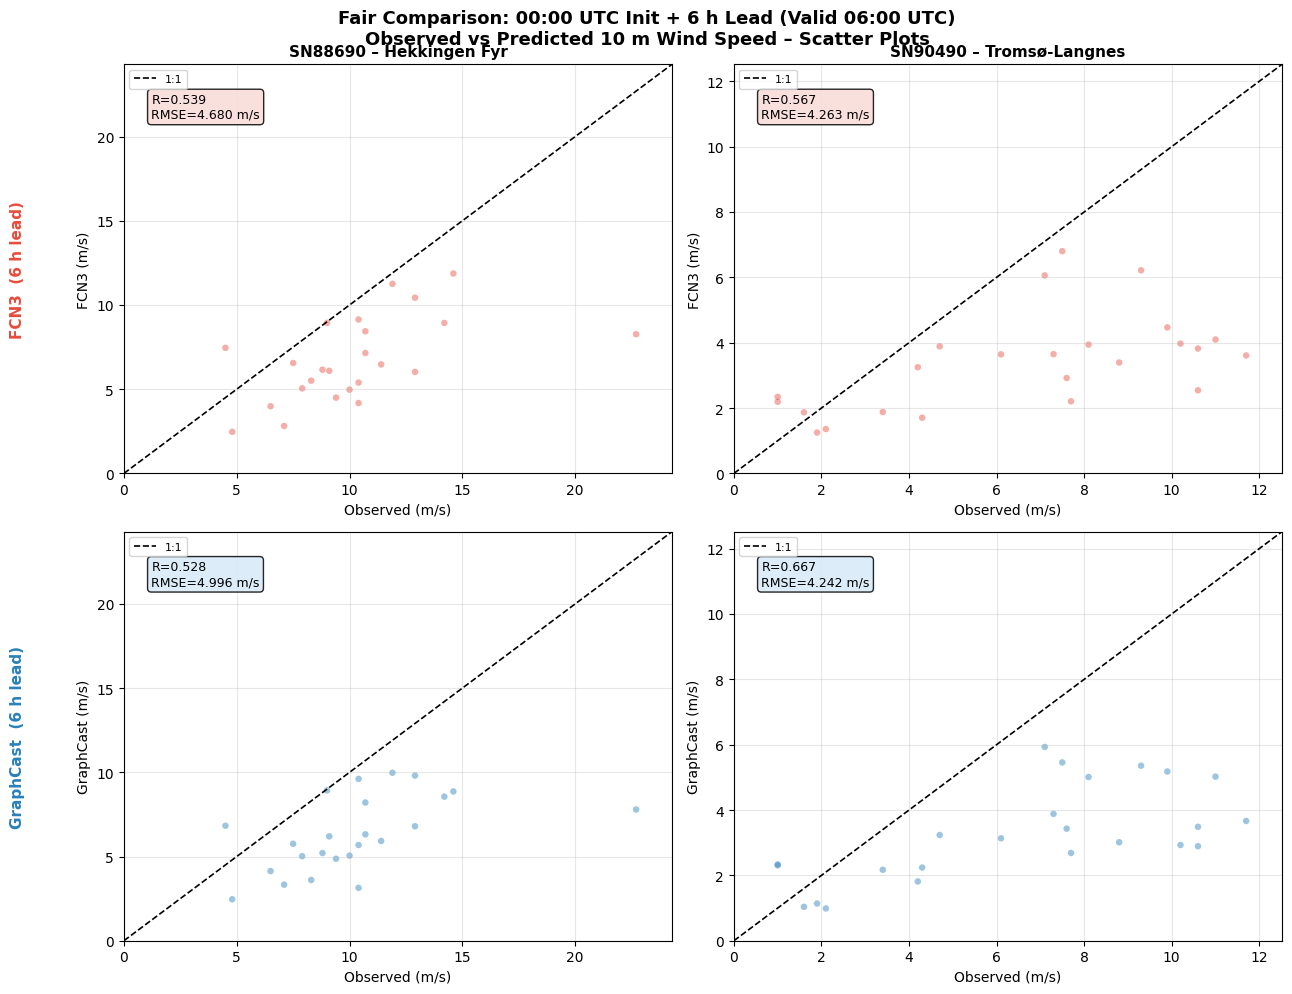

Saved: /cluster/home/siyan/github/WF-experiments/experiments/notebooks/figures/comparison_scatter.png


In [73]:
_n = len(STATIONS)
fig, axes = plt.subplots(2, _n, figsize=(5 * _n + 3, 10), squeeze=False)

for col, (sid, info) in enumerate(STATIONS.items()):
    sub  = merged[merged['station'] == sid]
    vmax = max(sub['obs_wind'].max(),
               sub['fcn3_wind'].max(),
               sub['gc_wind'].max()) * 1.07

    # ── Row 0: FCN3 ──────────────────────────────────────────────────────────
    ax = axes[0, col]
    ax.scatter(sub['obs_wind'], sub['fcn3_wind'],
               alpha=0.45, s=22, color=CLR['FCN3'], edgecolors='none')
    ax.plot([0, vmax], [0, vmax], 'k--', lw=1.2, label='1:1')
    ax.set_xlim(0, vmax);  ax.set_ylim(0, vmax)
    ax.set_xlabel('Observed (m/s)', fontsize=10)
    ax.set_ylabel('FCN3 (m/s)',     fontsize=10)
    ax.set_title(f'{sid} – {info["name"]}', fontsize=11, fontweight='bold')
    r_f = np.corrcoef(sub['obs_wind'], sub['fcn3_wind'])[0, 1]
    ax.text(0.05, 0.93,
            f'R={r_f:.3f}\nRMSE={metrics.loc[sid, "FCN3 RMSE"]:.3f} m/s',
            transform=ax.transAxes, fontsize=9, va='top',
            bbox=dict(boxstyle='round', facecolor='#FADBD8', alpha=0.85))
    ax.legend(fontsize=8);  ax.grid(alpha=0.3)

    # ── Row 1: GraphCast ─────────────────────────────────────────────────────
    ax = axes[1, col]
    ax.scatter(sub['obs_wind'], sub['gc_wind'],
               alpha=0.45, s=22, color=CLR['GraphCast'], edgecolors='none')
    ax.plot([0, vmax], [0, vmax], 'k--', lw=1.2, label='1:1')
    ax.set_xlim(0, vmax);  ax.set_ylim(0, vmax)
    ax.set_xlabel('Observed (m/s)',  fontsize=10)
    ax.set_ylabel('GraphCast (m/s)', fontsize=10)
    r_g = np.corrcoef(sub['obs_wind'], sub['gc_wind'])[0, 1]
    ax.text(0.05, 0.93,
            f'R={r_g:.3f}\nRMSE={metrics.loc[sid, "GC RMSE"]:.3f} m/s',
            transform=ax.transAxes, fontsize=9, va='top',
            bbox=dict(boxstyle='round', facecolor='#D6EAF8', alpha=0.85))
    ax.legend(fontsize=8);  ax.grid(alpha=0.3)

plt.tight_layout(rect=[0.05, 0, 1, 0.97])
for row_axes, label, clr in [
    (axes[0], 'FCN3  (6 h lead)',    CLR['FCN3']),
    (axes[1], 'GraphCast  (6 h lead)', CLR['GraphCast']),
]:
    bbox  = row_axes[0].get_position()
    y_mid = (bbox.y0 + bbox.y1) / 2
    fig.text(0.01, y_mid, label,
             va='center', rotation='vertical', fontsize=11,
             fontweight='bold', color=clr)

fig.suptitle(
    'Fair Comparison: 00:00 UTC Init + 6 h Lead (Valid 06:00 UTC)\n'
    'Observed vs Predicted 10 m Wind Speed – Scatter Plots',
    fontsize=13, fontweight='bold', y=0.99
)
out = FIG_DIR / 'comparison_scatter.png'
plt.savefig(out, dpi=130, bbox_inches='tight')
plt.show()
print(f'Saved: {out}')

## 8b  Visualize: FCN3 & GraphCast vs ERA5 Analysis (ERA5 as Reference)

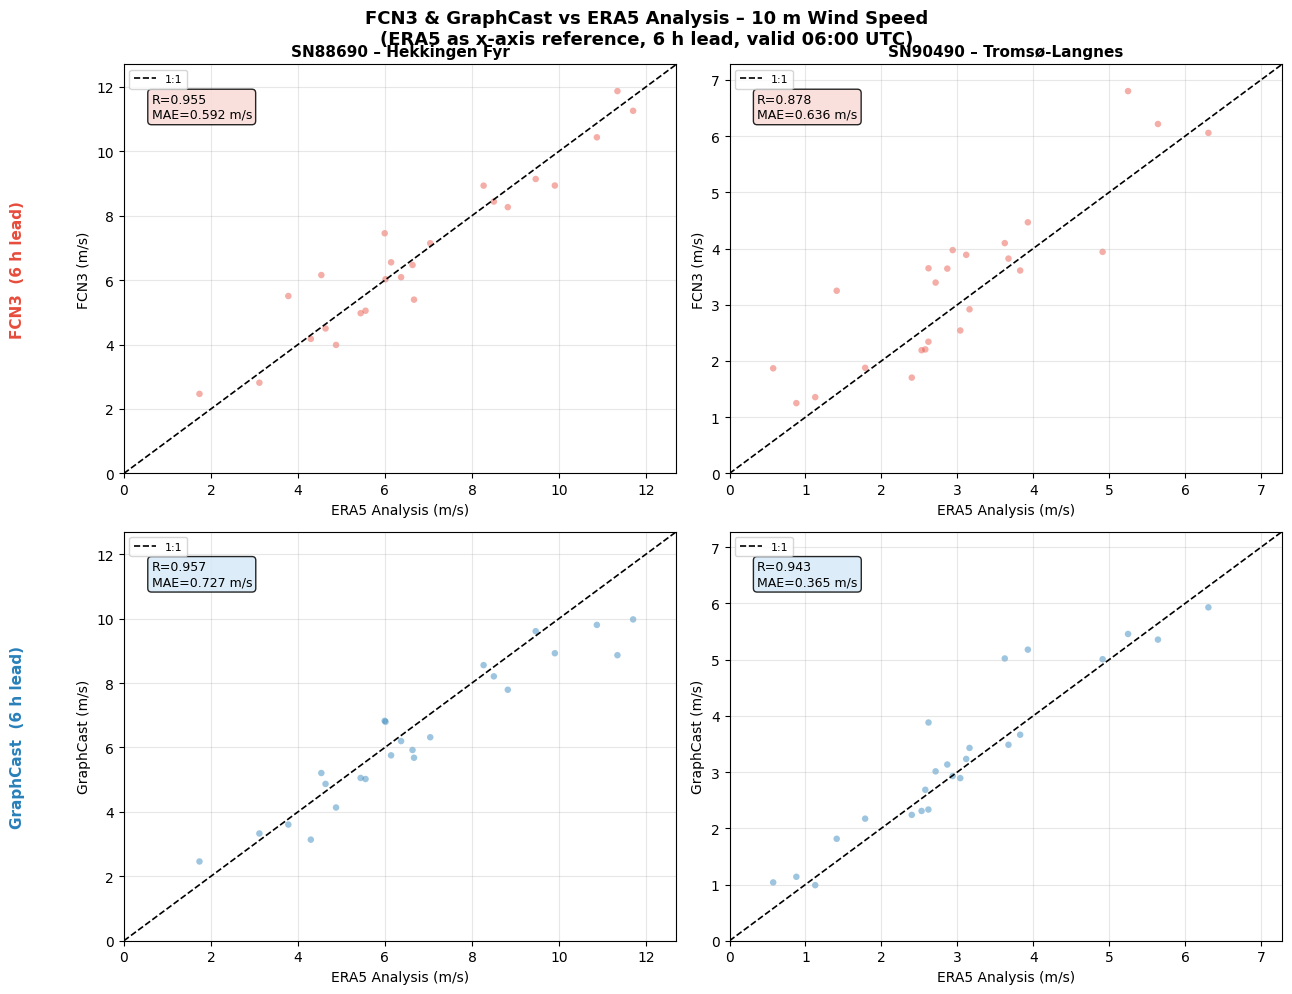

Saved: /cluster/home/siyan/github/WF-experiments/experiments/notebooks/figures/comparison_scatter_vs_era5.png


In [74]:
_n = len(STATIONS)
fig, axes = plt.subplots(2, _n, figsize=(5 * _n + 3, 10), squeeze=False)

for col, (sid, info) in enumerate(STATIONS.items()):
    sub  = merged[merged['station'] == sid].dropna(subset=['era5_wind'])
    vmax = max(sub['era5_wind'].max(),
               sub['fcn3_wind'].max(),
               sub['gc_wind'].max()) * 1.07

    # ── Row 0: FCN3 vs ERA5 ──────────────────────────────────────────────────
    ax = axes[0, col]
    ax.scatter(sub['era5_wind'], sub['fcn3_wind'],
               alpha=0.45, s=22, color=CLR['FCN3'], edgecolors='none')
    ax.plot([0, vmax], [0, vmax], 'k--', lw=1.2, label='1:1')
    ax.set_xlim(0, vmax);  ax.set_ylim(0, vmax)
    ax.set_xlabel('ERA5 Analysis (m/s)', fontsize=10)
    ax.set_ylabel('FCN3 (m/s)',          fontsize=10)
    ax.set_title(f'{sid} – {info["name"]}', fontsize=11, fontweight='bold')
    r_f = np.corrcoef(sub['era5_wind'], sub['fcn3_wind'])[0, 1]
    mae_f = float(np.abs(sub['fcn3_wind'] - sub['era5_wind']).mean())
    ax.text(0.05, 0.93,
            f'R={r_f:.3f}\nMAE={mae_f:.3f} m/s',
            transform=ax.transAxes, fontsize=9, va='top',
            bbox=dict(boxstyle='round', facecolor='#FADBD8', alpha=0.85))
    ax.legend(fontsize=8);  ax.grid(alpha=0.3)

    # ── Row 1: GraphCast vs ERA5 ─────────────────────────────────────────────
    ax = axes[1, col]
    ax.scatter(sub['era5_wind'], sub['gc_wind'],
               alpha=0.45, s=22, color=CLR['GraphCast'], edgecolors='none')
    ax.plot([0, vmax], [0, vmax], 'k--', lw=1.2, label='1:1')
    ax.set_xlim(0, vmax);  ax.set_ylim(0, vmax)
    ax.set_xlabel('ERA5 Analysis (m/s)', fontsize=10)
    ax.set_ylabel('GraphCast (m/s)',     fontsize=10)
    r_g = np.corrcoef(sub['era5_wind'], sub['gc_wind'])[0, 1]
    mae_g = float(np.abs(sub['gc_wind'] - sub['era5_wind']).mean())
    ax.text(0.05, 0.93,
            f'R={r_g:.3f}\nMAE={mae_g:.3f} m/s',
            transform=ax.transAxes, fontsize=9, va='top',
            bbox=dict(boxstyle='round', facecolor='#D6EAF8', alpha=0.85))
    ax.legend(fontsize=8);  ax.grid(alpha=0.3)

plt.tight_layout(rect=[0.05, 0, 1, 0.97])
for row_axes, label, clr in [
    (axes[0], 'FCN3  (6 h lead)',      CLR['FCN3']),
    (axes[1], 'GraphCast  (6 h lead)', CLR['GraphCast']),
]:
    bbox  = row_axes[0].get_position()
    y_mid = (bbox.y0 + bbox.y1) / 2
    fig.text(0.01, y_mid, label,
             va='center', rotation='vertical', fontsize=11,
             fontweight='bold', color=clr)

fig.suptitle(
    'FCN3 & GraphCast vs ERA5 Analysis – 10 m Wind Speed\n'
    '(ERA5 as x-axis reference, 6 h lead, valid 06:00 UTC)',
    fontsize=13, fontweight='bold', y=0.99
)
out = FIG_DIR / 'comparison_scatter_vs_era5.png'
plt.savefig(out, dpi=130, bbox_inches='tight')
plt.show()
print(f'Saved: {out}')

## 9  Summary Table

In [75]:
summary = metrics[['N', 'ERA5 RMSE', 'FCN3 RMSE', 'GC RMSE',
                        'ERA5 MSE',  'FCN3 MSE',  'GC MSE',
                        'ERA5 Bias', 'FCN3 Bias', 'GC Bias']].copy()
summary['ΔRMSE FCN3−ERA5'] = summary['FCN3 RMSE'] - summary['ERA5 RMSE']
summary['ΔRMSE GC−ERA5']   = summary['GC RMSE']   - summary['ERA5 RMSE']
summary['ΔRMSE GC−FCN3']   = summary['GC RMSE']   - summary['FCN3 RMSE']

print('Final Summary – Fair Comparison: 00:00 UTC init + 6 h lead (valid 06:00 UTC)')
print('=' * 100)
print(summary.round(4).to_string())
print()
print('Notes:')
print('  • ERA5       : analysis field at 06:00 UTC (lead = 0 h, no forecast)')
print('  • FCN3       : 6-hourly cycling init; 00:00 UTC init + 6 h lead → valid 06:00 UTC')
print('  • GraphCast  : 00:00 UTC init + 6 h lead → valid 06:00 UTC')
print('  • ΔRMSE < 0  : second model beats the reference')

Final Summary – Fair Comparison: 00:00 UTC init + 6 h lead (valid 06:00 UTC)
               N  ERA5 RMSE  FCN3 RMSE  GC RMSE  ERA5 MSE  FCN3 MSE   GC MSE  ERA5 Bias  FCN3 Bias  GC Bias  ΔRMSE FCN3−ERA5  ΔRMSE GC−ERA5  ΔRMSE GC−FCN3
Station                                                                                                                                                   
SN88690       24     4.6130     4.6803   4.9962   21.2801   21.9050  24.9616    -3.5157    -3.5025  -3.9190           0.0672         0.3831         0.3159
SN90490       24     4.4667     4.2635   4.2420   19.9517   18.1774  17.9943    -3.5065    -3.1932  -3.3069          -0.2032        -0.2248        -0.0215
All Stations  48     4.5405     4.4767   4.6344   20.6159   20.0412  21.4779    -3.5111    -3.3479  -3.6130          -0.0637         0.0940         0.1577

Notes:
  • ERA5       : analysis field at 06:00 UTC (lead = 0 h, no forecast)
  • FCN3       : 6-hourly cycling init; 00:00 UTC init + 6 h lead → v